## Pipeline `feature_engineering` — Features físicas para detecção de falha de motor

**Pipeline:** `feature_engineering`  
**Kedro node:** `engineer_features_for_all_flights_node`  
**Input:** `prepared_flights` → **Output:** `feature_engineered_flights` → `data/04_feature/`

---

Este notebook demonstra as features físicas criadas para detectar a falha de motor.  
A intuição central: **altitude e energia se comportam de formas complementares na falha**.
A altitude cai imediatamente (o autopilot inclina o nariz para baixo para manter velocidade de voo).
A energia específica permanece estável por alguns segundos enquanto o avião troca altitude por
velocidade — e depois cai de forma **monotônica e sustentada**, que é o sinal limpo para o modelo.

| Feature | Tipo | Por quê é útil |
|---|---|---|
| `energy_specific` | Física | Após ~2–3 s da falha, cai de forma monotônica — sinal mais limpo que altitude |
| `energy_rate` | Derivada | Ruidoso como sinal instantâneo; útil apenas suavizado (ver rolling slope) |
| `speed_horizontal` / `speed_total` | Cinemática | Complementa altitude para calcular energia |
| `glide_ratio` | Aerodinâmica | Converge para L/D do CarbonZ (~8) em planador |
| `control_effort` | Controle | O autopilot luta mais para compensar a falha |
| `*_mean_W` / `*_std_W` / `*_slope_W` | Temporais | Capturam tendências sustentadas, filtrando picos transitórios |

> **Para rodar toda a pipeline no Kedro:** `kedro run --pipeline=feature_engineering`

## Imports e parâmetros (feature_engineering)

In [1]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd

from aeroespacial_2.pipelines.feature_engineering.nodes import (
    FFT_TARGET_FEATURES,
    ROLLING_TARGET_FEATURES,
    compute_control_effort,
    compute_energy_rate,
    compute_fft_features,
    compute_glide_ratio,
    compute_rolling_features,
    compute_specific_energy,
    compute_velocity_magnitudes,
    engineer_features,
)

# Espelha conf/base/parameters.yml → feature_engineering
FLIGHT_NAME = "carbonZ_2018-07-18-15-53-31_1_engine_failure"
PREPARED_DATA = "../data/03_primary/carbonZ_2018-07-18-15-53-31_1_engine_failure.csv"
ROLLING_WINDOWS = [50, 100, 200]  # amostras: ~0.5 s, ~1 s, ~2 s a 100 Hz
FFT_WINDOWS = [500, 1000, 2000]    

## Carregamento e overview do voo

In [2]:
df_prepared = pd.read_csv(PREPARED_DATA)

# Informações básicas do voo
dt = df_prepared["timestamp"].diff().median()
duration = df_prepared["timestamp"].max()
fault_onset = df_prepared.loc[df_prepared["target_fault"] == 1, "timestamp"].min()
fault_frac = (df_prepared["target_fault"] == 1).mean() * 100

print(f"Shape: {df_prepared.shape}")
print(f"Taxa de amostragem estimada: {1/dt:.1f} Hz  (dt mediano = {dt*1000:.2f} ms)")
print(f"Duração total do voo: {duration:.1f} s")
print(f"Início da falha: {fault_onset:.1f} s ({fault_frac:.1f}% do voo em falha)")
print(f"Janelas rolling em amostras {ROLLING_WINDOWS} ≈ {[round(w*dt, 2) for w in ROLLING_WINDOWS]} segundos")

Shape: (25994, 60)
Taxa de amostragem estimada: 523.5 Hz  (dt mediano = 1.91 ms)
Duração total do voo: 131.4 s
Início da falha: 115.3 s (12.4% do voo em falha)
Janelas rolling em amostras [50, 100, 200] ≈ [np.float64(0.1), np.float64(0.19), np.float64(0.38)] segundos


## Feature 1 — Energia mecânica específica: h + v²/(2g)

Em voo propulsionado, o motor injeta energia para compensar o arrasto.
Sem motor, o arrasto dissipa energia sem reposição — o sistema perde energia total.

O comportamento observado nos dados tem três fases distintas:

1. **Imediatamente na falha:** a `alt_global` começa a cair. O autopilot inclina o nariz
   para baixo para manter a velocidade de voo (evitar stall). Altitude **não** é um indicador
   atrasado — é contemporâneo à falha.

2. **Primeiros ~2–3 s após a falha:** a `energy_specific` permanece estável. O avião está
   trocando altitude por velocidade (energia potencial → cinética), mantendo a soma
   h + v²/2g aproximadamente constante. A energia não é dissipada ainda, apenas redistribuída.

3. **A partir de ~2–3 s:** o arrasto acumula dissipação suficiente para superar a troca PE↔KE.
   A `energy_specific` começa a cair de forma **quase monotônica** — sinal mais limpo e
   sustentado do que a altitude, que pode oscilar por manobras normais.

A `energy_rate` (derivada instantânea) é **ruidosa**: apresenta picos positivos e negativos
tanto no voo normal quanto na falha. O sinal útil emerge apenas quando suavizado em janelas
temporais — ver Feature 4 (`energy_specific_slope_W`).

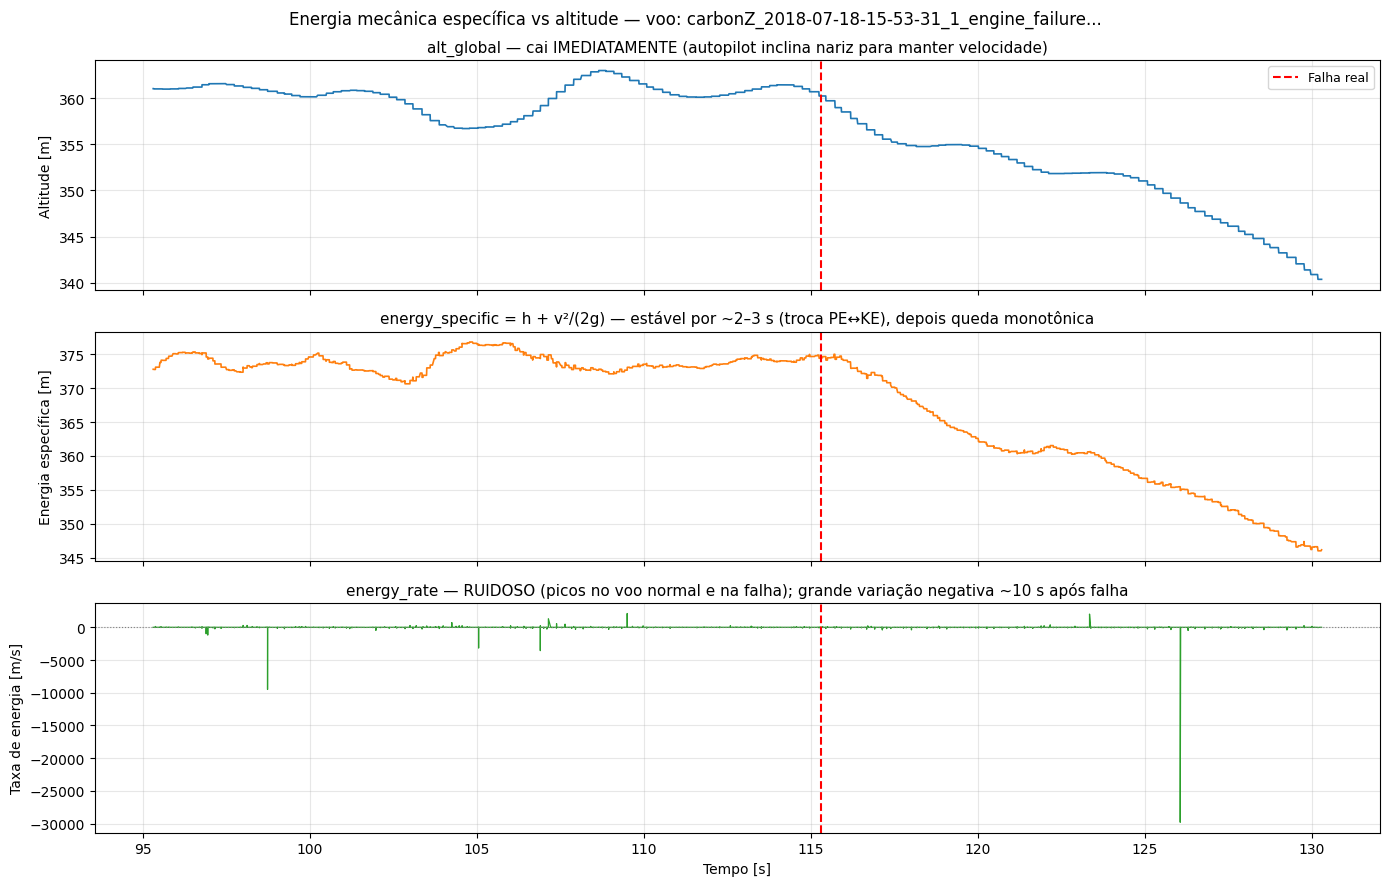

Shape após compute_specific_energy + compute_energy_rate: (25994, 62)
Colunas adicionadas: energy_specific, energy_rate


In [3]:
df = compute_specific_energy(df_prepared)
df = compute_energy_rate(df)

# Janela de visualização: 20 s antes até 15 s depois da falha
t0, t1 = fault_onset - 20, fault_onset + 15
view = df[(df["timestamp"] >= t0) & (df["timestamp"] <= t1)]

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

# Altitude — cai imediatamente com a falha
axes[0].plot(view["timestamp"], view["alt_global"], color="tab:blue", linewidth=1.2)
axes[0].axvline(fault_onset, color="red", linewidth=1.5, linestyle="--", label="Falha real")
axes[0].set_ylabel("Altitude [m]", fontsize=10)
axes[0].set_title("alt_global — cai IMEDIATAMENTE (autopilot inclina nariz para manter velocidade)", fontsize=11)
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Energia específica — estável por ~2–3 s (PE↔KE), depois queda monotônica
axes[1].plot(view["timestamp"], view["energy_specific"], color="tab:orange", linewidth=1.2)
axes[1].axvline(fault_onset, color="red", linewidth=1.5, linestyle="--")
axes[1].set_ylabel("Energia específica [m]", fontsize=10)
axes[1].set_title("energy_specific = h + v²/(2g) — estável por ~2–3 s (troca PE↔KE), depois queda monotônica", fontsize=11)
axes[1].grid(True, alpha=0.3)

# Taxa de variação de energia — ruidosa, picos em todo o voo
axes[2].plot(view["timestamp"], view["energy_rate"], color="tab:green", linewidth=0.9)
axes[2].axhline(0, color="gray", linewidth=0.8, linestyle=":")
axes[2].axvline(fault_onset, color="red", linewidth=1.5, linestyle="--")
axes[2].set_ylabel("Taxa de energia [m/s]", fontsize=10)
axes[2].set_xlabel("Tempo [s]", fontsize=10)
axes[2].set_title("energy_rate — RUIDOSO (picos no voo normal e na falha); grande variação negativa ~10 s após falha", fontsize=11)
axes[2].grid(True, alpha=0.3)

plt.suptitle(
    f"Energia mecânica específica vs altitude — voo: {FLIGHT_NAME[:50]}...",
    fontsize=12,
)
plt.tight_layout()
plt.show()

print(f"Shape após compute_specific_energy + compute_energy_rate: {df.shape}")
print(f"Colunas adicionadas: energy_specific, energy_rate")

## Feature 2 — Velocidades e razão de planeio

**Velocidades horizontal e total** caem de forma consistente logo após a falha: sem thrust, o
arrasto desacelera o avião sem compensação.

**`vel_z_meas`** é positivo e oscilante após a falha. A convenção no dataset é NED
(North-East-Down): **positivo = descendo**. Antes da falha, oscila em torno de zero
(altitude mantida pelo autopilot). Após a falha, fica sempre positivo: o avião desce
sem recuperação.

**`glide_ratio`** tem um comportamento característico, mas que requer atenção na interpretação:
durante o voo normal ele oscila, mas há episódios curtos de constância — momentos de voo
nivelado em velocidade estável, onde o motor e a aerodinâmica estão em equilíbrio temporário.
O que muda após a falha **não é apenas a constância, mas a permanência dela**: o avião entra
num planeio puro e o `glide_ratio` converge para o L/D aerodinâmico do CarbonZ (~8) e
**nunca mais oscila** pelo restante do voo.

O discriminador correto portanto não é "está constante agora?" mas sim
"está constante de forma **sustentada**?" — exatamente o que `glide_ratio_std_W` com
janela longa captura: seu valor cai para próximo de zero após a falha e permanece assim.

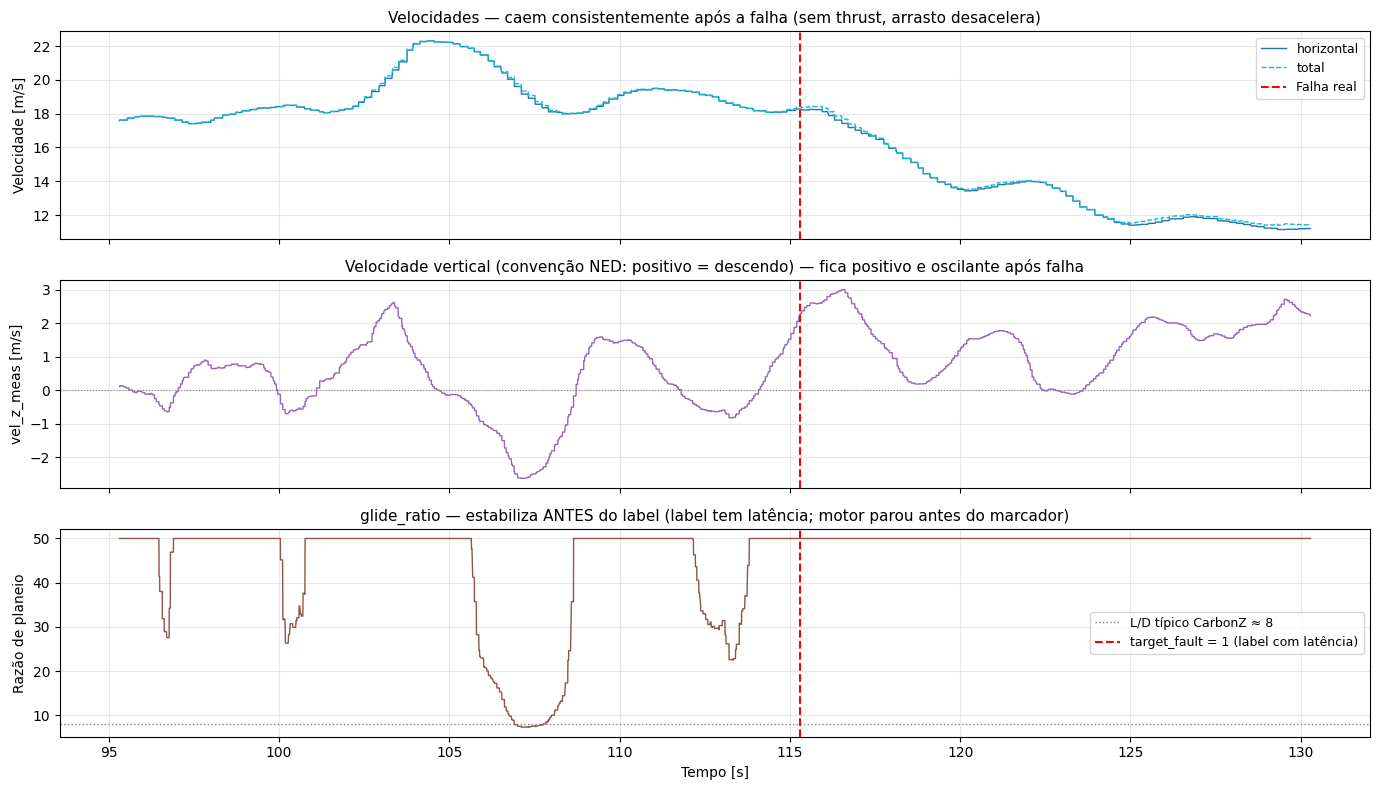

Shape após velocidades + glide_ratio: (25994, 65)
Colunas adicionadas: speed_horizontal, speed_total, glide_ratio


In [ ]:
df = compute_velocity_magnitudes(df)
df = compute_glide_ratio(df)

view = df[(df["timestamp"] >= t0) & (df["timestamp"] <= t1)]

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

axes[0].plot(view["timestamp"], view["speed_horizontal"], color="tab:blue", linewidth=1.0, label="horizontal")
axes[0].plot(view["timestamp"], view["speed_total"], color="tab:cyan", linewidth=1.0, linestyle="--", label="total")
axes[0].axvline(fault_onset, color="red", linewidth=1.5, linestyle="--", label="Falha real")
axes[0].set_ylabel("Velocidade [m/s]", fontsize=10)
axes[0].set_title("Velocidades — caem consistentemente após a falha (sem thrust, arrasto desacelera)", fontsize=11)
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].plot(view["timestamp"], view["vel_z_meas"], color="tab:purple", linewidth=1.0)
axes[1].axhline(0, color="gray", linewidth=0.8, linestyle=":")
axes[1].axvline(fault_onset, color="red", linewidth=1.5, linestyle="--")
axes[1].set_ylabel("vel_z_meas [m/s]", fontsize=10)
axes[1].set_title("Velocidade vertical (convenção NED: positivo = descendo) — fica positivo e oscilante após falha", fontsize=11)
axes[1].grid(True, alpha=0.3)

axes[2].plot(view["timestamp"], view["glide_ratio"], color="tab:brown", linewidth=1.0)
axes[2].axhline(8, color="gray", linewidth=1.0, linestyle=":", label="L/D típico CarbonZ ≈ 8")
axes[2].axvline(fault_onset, color="red", linewidth=1.5, linestyle="--", label="target_fault = 1 (label com latência)")
axes[2].set_ylabel("Razão de planeio", fontsize=10)
axes[2].set_xlabel("Tempo [s]", fontsize=10)
axes[2].set_title("glide_ratio", fontsize=11)
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Shape após velocidades + glide_ratio: {df.shape}")
print(f"Colunas adicionadas: speed_horizontal, speed_total, glide_ratio")

## Feature 3 — Esforço de controle

Quando o motor falha, o autopilot continua comandando valores normais enquanto
o avião diverge do setpoint. Todos os erros de rastreamento crescem simultaneamente.
Somar seus quadrados cria um escalar composto que amplifica o sinal de falha.

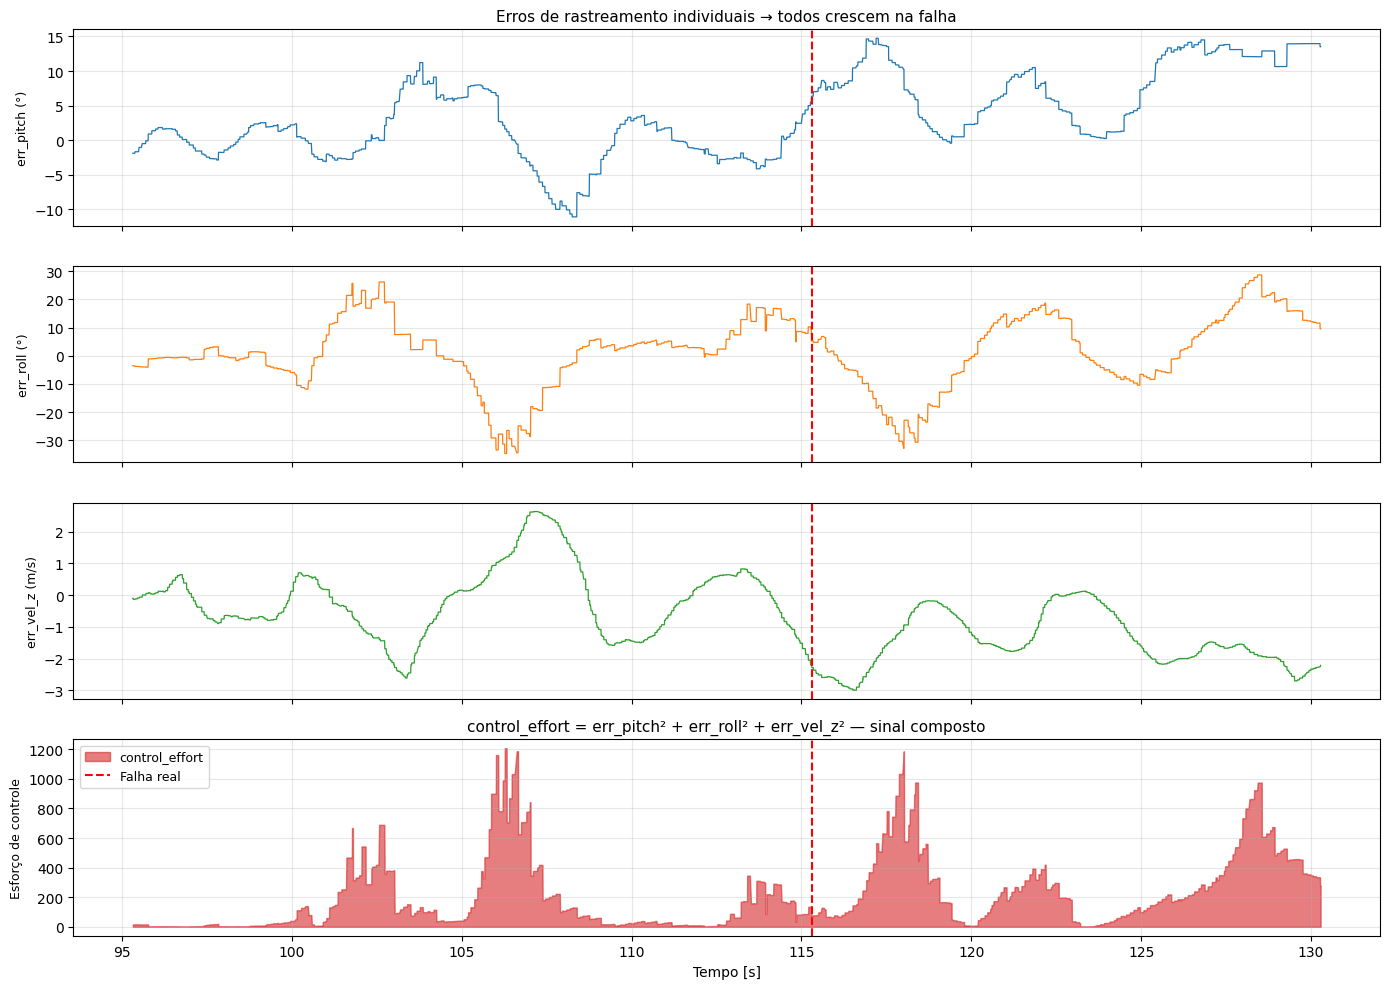

Shape após control_effort: (25994, 66)
Colunas adicionadas: control_effort


In [5]:
df = compute_control_effort(df)

view = df[(df["timestamp"] >= t0) & (df["timestamp"] <= t1)]

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

for ax, col, color, label in zip(
    axes[:3],
    ["err_pitch", "err_roll", "err_vel_z"],
    ["tab:blue", "tab:orange", "tab:green"],
    ["err_pitch (°)", "err_roll (°)", "err_vel_z (m/s)"],
):
    ax.plot(view["timestamp"], view[col], color=color, linewidth=0.9)
    ax.axvline(fault_onset, color="red", linewidth=1.5, linestyle="--")
    ax.set_ylabel(label, fontsize=9)
    ax.grid(True, alpha=0.3)

axes[0].set_title("Erros de rastreamento individuais → todos crescem na falha", fontsize=11)

axes[3].fill_between(
    view["timestamp"], view["control_effort"], alpha=0.6, color="tab:red", label="control_effort"
)
axes[3].axvline(fault_onset, color="red", linewidth=1.5, linestyle="--", label="Falha real")
axes[3].set_ylabel("Esforço de controle", fontsize=9)
axes[3].set_xlabel("Tempo [s]", fontsize=10)
axes[3].set_title("control_effort = err_pitch² + err_roll² + err_vel_z² — sinal composto", fontsize=11)
axes[3].legend(fontsize=9)
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Shape após control_effort: {df.shape}")
print(f"Colunas adicionadas: control_effort")

## Feature 4 — Estatísticas de janela temporal (rolling)

Valores instantâneos capturam o estado *agora*. Estatísticas de janela capturam *tendências*.
Para cada feature relevante, calculamos:
- **mean\_W**: nível suavizado do sinal sobre a janela
- **std\_W**: variabilidade local (picos na falha)
- **slope\_W**: taxa de variação média [unidade/s] sobre a janela

O `slope` de `energy_specific` é o substituto mais confiável para `energy_rate`:
ao calcular a variação sobre uma janela inteira em vez do diferencial instantâneo,
ele filtra os picos transitórios e revela a **tendência sustentada negativa** que
caracteriza a falha do motor — distinguindo-a de manobras normais ou rajadas de vento.

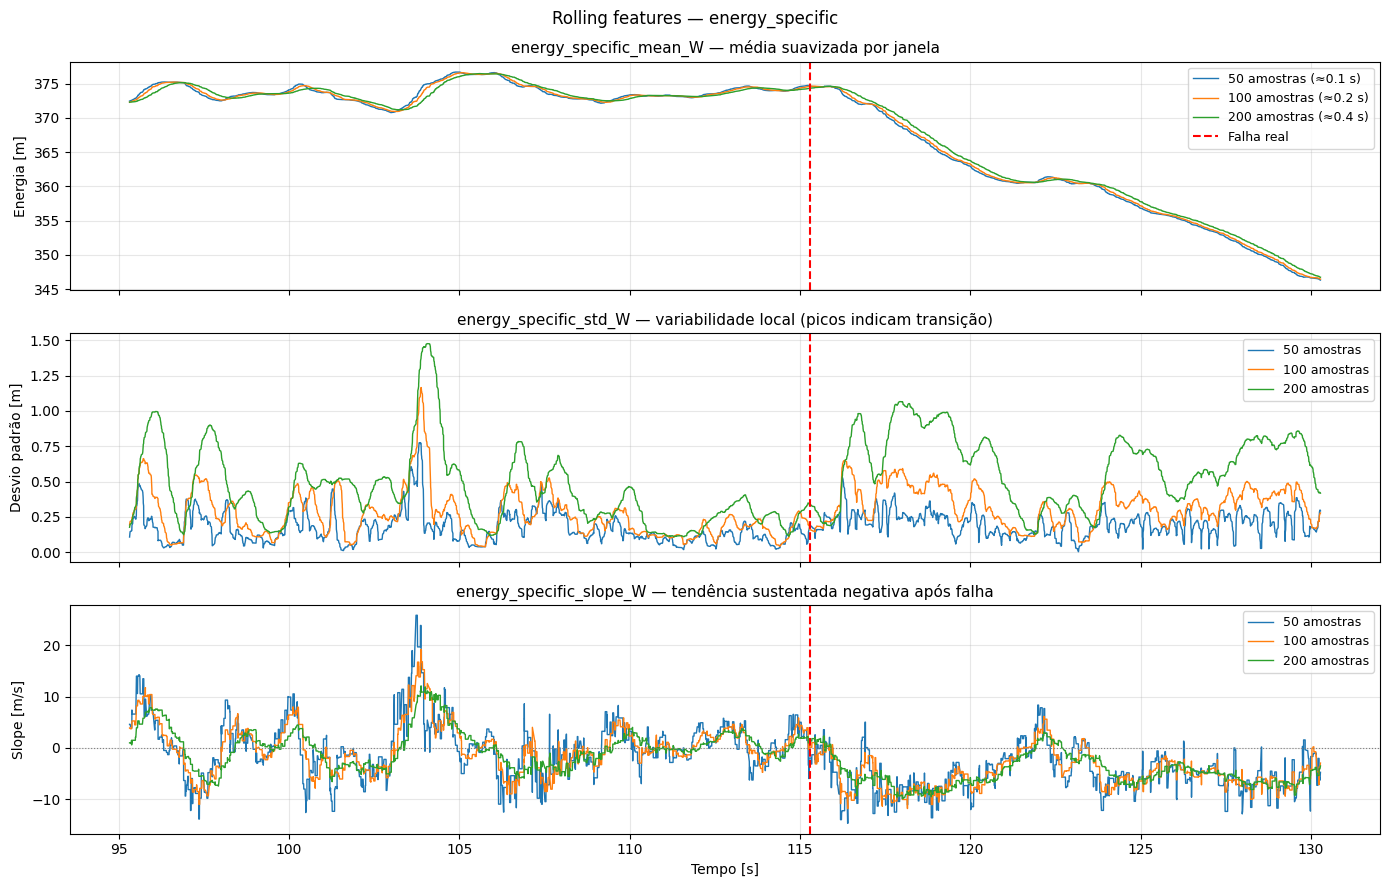

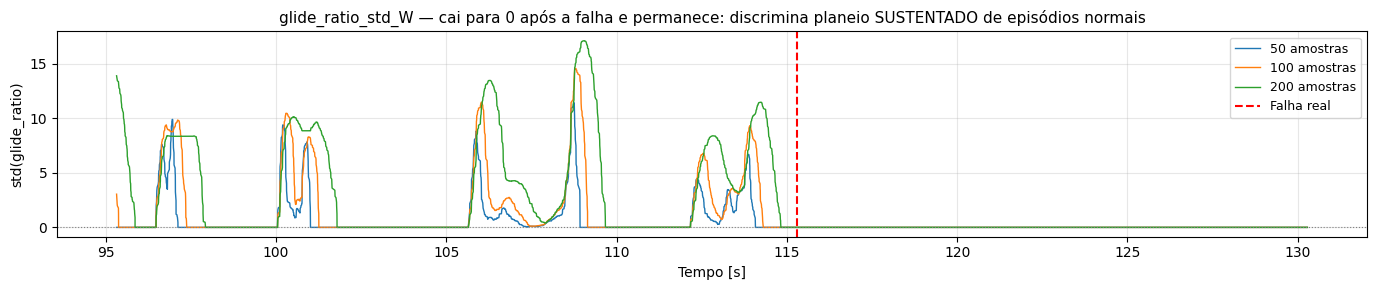

Shape após rolling features: (25994, 129)
Colunas rolling criadas: 63


In [6]:
from aeroespacial_2.pipelines.feature_engineering.nodes import ROLLING_TARGET_FEATURES

rolling_feats = [f for f in ROLLING_TARGET_FEATURES if f in df.columns]
df = compute_rolling_features(df, ROLLING_WINDOWS, rolling_feats)

view = df[(df["timestamp"] >= t0) & (df["timestamp"] <= t1)]

colors = ["tab:blue", "tab:orange", "tab:green"]
windows_labels = [f"{w} amostras (≈{round(w*dt,1)} s)" for w in ROLLING_WINDOWS]

# --- energy_specific rolling ---
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

for w, color, label in zip(ROLLING_WINDOWS, colors, windows_labels):
    axes[0].plot(view["timestamp"], view[f"energy_specific_mean_{w}"], color=color, linewidth=1.0, label=label)
axes[0].axvline(fault_onset, color="red", linewidth=1.5, linestyle="--", label="Falha real")
axes[0].set_ylabel("Energia [m]", fontsize=10)
axes[0].set_title("energy_specific_mean_W — média suavizada por janela", fontsize=11)
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

for w, color in zip(ROLLING_WINDOWS, colors):
    axes[1].plot(view["timestamp"], view[f"energy_specific_std_{w}"], color=color, linewidth=1.0, label=f"{w} amostras")
axes[1].axvline(fault_onset, color="red", linewidth=1.5, linestyle="--")
axes[1].set_ylabel("Desvio padrão [m]", fontsize=10)
axes[1].set_title("energy_specific_std_W — variabilidade local (picos indicam transição)", fontsize=11)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

for w, color in zip(ROLLING_WINDOWS, colors):
    axes[2].plot(view["timestamp"], view[f"energy_specific_slope_{w}"], color=color, linewidth=1.0, label=f"{w} amostras")
axes[2].axhline(0, color="gray", linewidth=0.8, linestyle=":")
axes[2].axvline(fault_onset, color="red", linewidth=1.5, linestyle="--")
axes[2].set_ylabel("Slope [m/s]", fontsize=10)
axes[2].set_xlabel("Tempo [s]", fontsize=10)
axes[2].set_title("energy_specific_slope_W — tendência sustentada negativa após falha", fontsize=11)
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3)

plt.suptitle("Rolling features — energy_specific", fontsize=12)
plt.tight_layout()
plt.show()

# --- glide_ratio_std rolling — discriminador de planeio sustentado ---
fig, axes = plt.subplots(1, 1, figsize=(14, 3))

for w, color in zip(ROLLING_WINDOWS, colors):
    axes.plot(view["timestamp"], view[f"glide_ratio_std_{w}"], color=color, linewidth=1.0, label=f"{w} amostras")
axes.axvline(fault_onset, color="red", linewidth=1.5, linestyle="--", label="Falha real")
axes.axhline(0, color="gray", linewidth=0.8, linestyle=":")
axes.set_ylabel("std(glide_ratio)", fontsize=10)
axes.set_xlabel("Tempo [s]", fontsize=10)
axes.set_title(
    "glide_ratio_std_W — cai para 0 após a falha e permanece: discrimina planeio SUSTENTADO de episódios normais",
    fontsize=11,
)
axes.legend(fontsize=9)
axes.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

new_rolling_cols = [c for c in df.columns if any(f"{feat}_" in c for feat in rolling_feats)]
print(f"Shape após rolling features: {df.shape}")
print(f"Colunas rolling criadas: {len(new_rolling_cols)}")

## Feature 5 — Espectro de frequências (FFT rolling)

As features de tempo capturam *o quanto* um sinal muda. O domínio de frequência captura
*como* ele oscila — um tipo de informação que é invisível para o Isolation Forest operando
com features de magnitude.

**Por que FFT ajuda na detecção de falha de motor?**

Uma falha de motor tem precursores espectrais antes de ser detectável no tempo:
- O motor degradando cria oscilações periódicas na velocidade (`aspd_meas`) por ripple de
  thrust e desequilíbrio da hélice
- A energia específica, que em cruzeiro normal é quasi-constante (espectro de baixa frequência),
  começa a oscilar de forma caótica antes da queda monotônica
- Manobras normais têm energia concentrada em baixas frequências; eventos de falha injetam
  energia em altas frequências

Para cada sinal e tamanho de janela, três descritores são extraídos:

| Feature | O que captura |
|---|---|
| `fft_peak_power_{sinal}_{w}` | Magnitude do componente de frequência dominante (excluindo DC) |
| `fft_entropy_{sinal}_{w}` | Entropia espectral de Shannon [0–1]: 0 = puro senoide, 1 = ruído branco |
| `fft_high_ratio_{sinal}_{w}` | Fração da potência espectral na metade superior da banda |

**Implementação:** usa `sliding_window_view` + batch `rfft` vetorizado — sem loop Python por amostra.

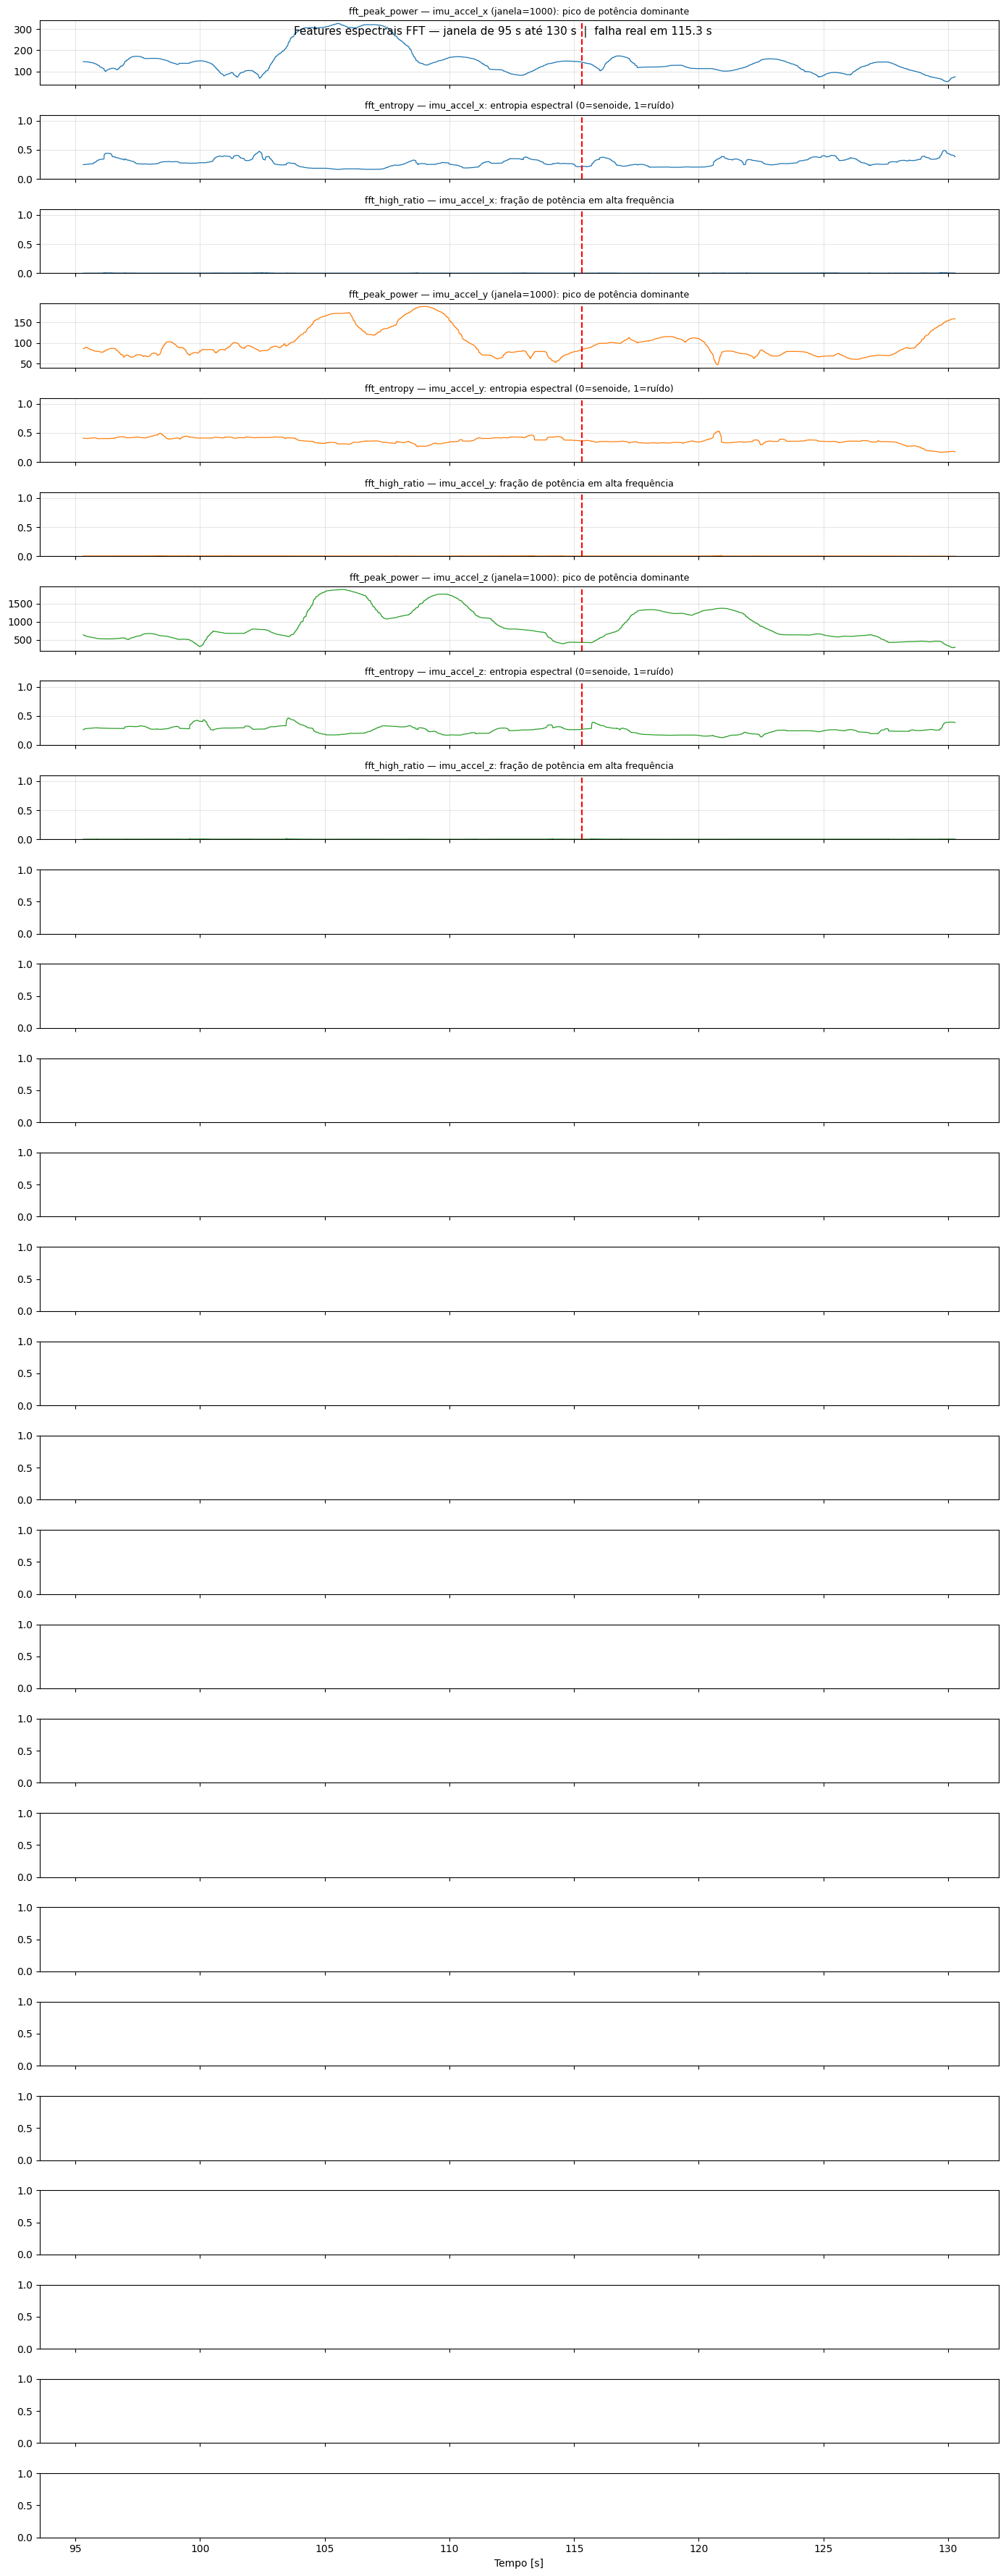

Shape após compute_fft_features: (25994, 210)
Features FFT criadas (81):
  fft_peak_power_imu_accel_x_500
  fft_entropy_imu_accel_x_500
  fft_high_ratio_imu_accel_x_500
  fft_peak_power_imu_accel_x_1000
  fft_entropy_imu_accel_x_1000
  fft_high_ratio_imu_accel_x_1000
  fft_peak_power_imu_accel_x_2000
  fft_entropy_imu_accel_x_2000
  fft_high_ratio_imu_accel_x_2000
  fft_peak_power_imu_accel_y_500
  fft_entropy_imu_accel_y_500
  fft_high_ratio_imu_accel_y_500
  fft_peak_power_imu_accel_y_1000
  fft_entropy_imu_accel_y_1000
  fft_high_ratio_imu_accel_y_1000
  fft_peak_power_imu_accel_y_2000
  fft_entropy_imu_accel_y_2000
  fft_high_ratio_imu_accel_y_2000
  fft_peak_power_imu_accel_z_500
  fft_entropy_imu_accel_z_500
  fft_high_ratio_imu_accel_z_500
  fft_peak_power_imu_accel_z_1000
  fft_entropy_imu_accel_z_1000
  fft_high_ratio_imu_accel_z_1000
  fft_peak_power_imu_accel_z_2000
  fft_entropy_imu_accel_z_2000
  fft_high_ratio_imu_accel_z_2000
  fft_peak_power_mag_x_500
  fft_entropy_mag_

In [7]:
# Computa FFT features sobre o voo de exemplo (requer energy_specific já calculado)
df_fft = compute_fft_features(df, FFT_WINDOWS, [f for f in FFT_TARGET_FEATURES if f in df.columns])

view_fft = df_fft[(df_fft["timestamp"] >= t0) & (df_fft["timestamp"] <= t1)]

sinais = [f for f in FFT_TARGET_FEATURES if f in df_fft.columns]
cores = ["tab:blue", "tab:orange", "tab:green"]
w_ref = FFT_WINDOWS[1]  # janela de referência para visualização

fig, axes = plt.subplots(len(sinais) * 3, 1, figsize=(14, 4 * len(sinais)), sharex=True)

for i, (sinal, cor) in enumerate(zip(sinais, cores)):
    base_ax = i * 3

    # Peak power
    axes[base_ax].plot(view_fft["timestamp"], view_fft[f"fft_peak_power_{sinal}_{w_ref}"],
                       color=cor, linewidth=0.9)
    axes[base_ax].axvline(fault_onset, color="red", lw=1.5, ls="--")
    axes[base_ax].set_title(f"fft_peak_power — {sinal} (janela={w_ref}): pico de potência dominante", fontsize=9)
    axes[base_ax].grid(True, alpha=0.3)

    # Spectral entropy
    axes[base_ax + 1].plot(view_fft["timestamp"], view_fft[f"fft_entropy_{sinal}_{w_ref}"],
                            color=cor, linewidth=0.9)
    axes[base_ax + 1].axvline(fault_onset, color="red", lw=1.5, ls="--")
    axes[base_ax + 1].set_ylim(0, 1.1)
    axes[base_ax + 1].set_title(f"fft_entropy — {sinal}: entropia espectral (0=senoide, 1=ruído)", fontsize=9)
    axes[base_ax + 1].grid(True, alpha=0.3)

    # High-frequency ratio
    axes[base_ax + 2].plot(view_fft["timestamp"], view_fft[f"fft_high_ratio_{sinal}_{w_ref}"],
                            color=cor, linewidth=0.9)
    axes[base_ax + 2].axvline(fault_onset, color="red", lw=1.5, ls="--")
    axes[base_ax + 2].set_ylim(0, 1.1)
    axes[base_ax + 2].set_title(f"fft_high_ratio — {sinal}: fração de potência em alta frequência", fontsize=9)
    axes[base_ax + 2].grid(True, alpha=0.3)

axes[-1].set_xlabel("Tempo [s]", fontsize=10)
plt.suptitle(
    f"Features espectrais FFT — janela de {t0:.0f} s até {t1:.0f} s  |  falha real em {fault_onset:.1f} s",
    fontsize=11,
)
plt.tight_layout()
plt.show()

fft_cols = [c for c in df_fft.columns if c.startswith("fft_")]
print(f"Shape após compute_fft_features: {df_fft.shape}")
print(f"Features FFT criadas ({len(fft_cols)}):")
for c in fft_cols:
    print(f"  {c}")

## Comparação: quando cada feature detecta a falha?

Aqui aplicamos a pipeline completa e comparamos o comportamento de cada família de
features **nos instantes ao redor da falha**. O objetivo é verificar se alguma feature
mostra sinal *antes* do `target_fault` virar 1.

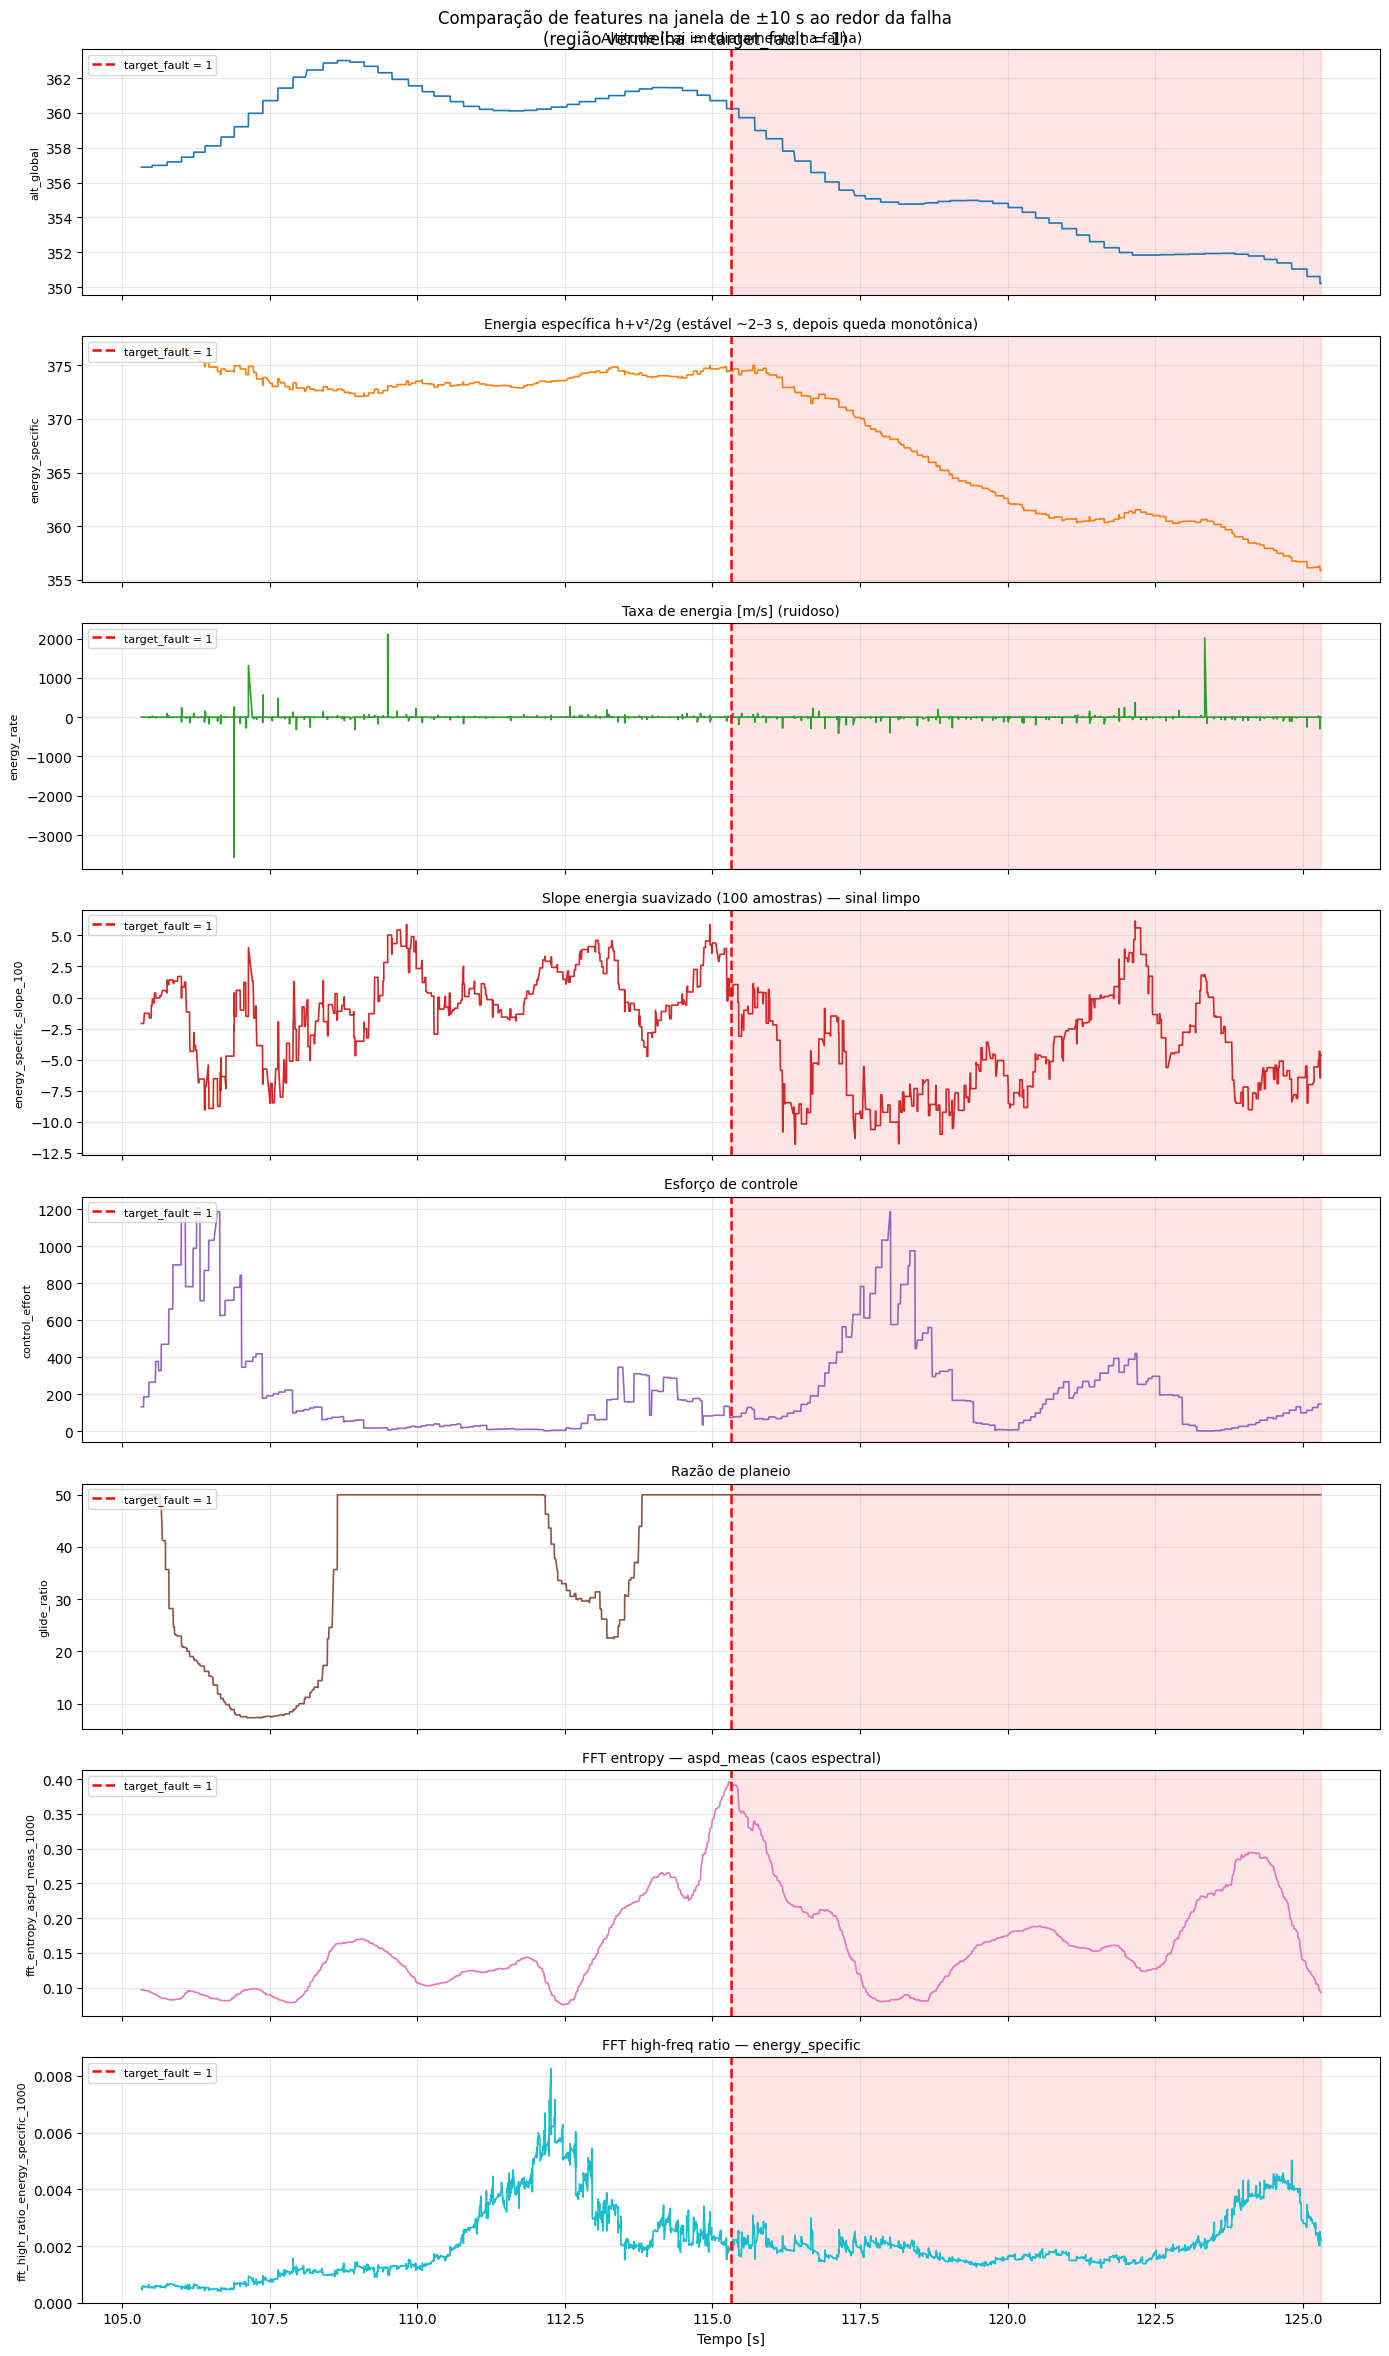

In [8]:
df_feat = engineer_features(df_prepared, ROLLING_WINDOWS, FFT_WINDOWS)

# Janela estreita: 10 s antes até 10 s depois da falha
t0_close, t1_close = fault_onset - 10, fault_onset + 10
close = df_feat[(df_feat["timestamp"] >= t0_close) & (df_feat["timestamp"] <= t1_close)]

features_to_compare = [
    ("alt_global",                   "Altitude (cai imediatamente na falha)",           "tab:blue"),
    ("energy_specific",              "Energia específica h+v²/2g (estável ~2–3 s, depois queda monotônica)", "tab:orange"),
    ("energy_rate",                  "Taxa de energia [m/s] (ruidoso)",                 "tab:green"),
    (f"energy_specific_slope_{ROLLING_WINDOWS[1]}", f"Slope energia suavizado ({ROLLING_WINDOWS[1]} amostras) — sinal limpo", "tab:red"),
    ("control_effort",               "Esforço de controle",                             "tab:purple"),
    ("glide_ratio",                  "Razão de planeio",                                "tab:brown"),
    (f"fft_entropy_aspd_meas_{FFT_WINDOWS[1]}",     "FFT entropy — aspd_meas (caos espectral)",       "tab:pink"),
    (f"fft_high_ratio_energy_specific_{FFT_WINDOWS[1]}", "FFT high-freq ratio — energy_specific",  "tab:cyan"),
]

fig, axes = plt.subplots(len(features_to_compare), 1, figsize=(14, 3 * len(features_to_compare)), sharex=True)

for ax, (col, title, color) in zip(axes, features_to_compare):
    ax.plot(close["timestamp"], close[col], color=color, linewidth=1.2)
    # Sombrear período de falha
    ax.axvspan(fault_onset, t1_close, alpha=0.10, color="red")
    ax.axvline(fault_onset, color="red", linewidth=1.8, linestyle="--", label="target_fault = 1")
    ax.set_ylabel(col, fontsize=8)
    ax.set_title(title, fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, loc="upper left")

axes[-1].set_xlabel("Tempo [s]", fontsize=10)
plt.suptitle(
    "Comparação de features na janela de ±10 s ao redor da falha\n"
    "(região vermelha = target_fault = 1)",
    fontsize=12,
)
plt.tight_layout()
plt.show()

## Resultado — shape final e colunas criadas

In [9]:
original_cols = set(df_prepared.columns)
new_cols = [c for c in df_feat.columns if c not in original_cols]

print(f"Shape original  (df_prepared):       {df_prepared.shape}")
print(f"Shape final     (df_feat):            {df_feat.shape}")
print(f"Features novas criadas:               {len(new_cols)}")
print()
print(f"{'Feature nova':<45} {'std':>10}")
print("-" * 57)
for col in new_cols:
    print(f"  {col:<43} {df_feat[col].std():>10.4f}")

Shape original  (df_prepared):       (25994, 60)
Shape final     (df_feat):            (25994, 210)
Features novas criadas:               150

Feature nova                                         std
---------------------------------------------------------
  energy_specific                                 5.7814
  energy_rate                                   446.1506
  speed_horizontal                                2.1579
  speed_total                                     2.1398
  glide_ratio                                    14.4927
  control_effort                                282.6258
  energy_specific_mean_50                         5.7262
  energy_specific_std_50                          0.1118
  energy_specific_slope_50                        5.6254
  energy_specific_mean_100                        5.6687
  energy_specific_std_100                         0.1682
  energy_specific_slope_100                       4.8316
  energy_specific_mean_200                        5.5494
 

## Próximos passos

O DataFrame `df_feat` (salvo em `data/04_feature/`) é o input para `model_training`.

Para usar as features de engenharia no modelo, atualize `model_training` para ler de
`feature_engineered_flights` em vez de `prepared_flights` no catalog.

---

**Ajuste de parâmetros** em `conf/base/parameters.yml`:
```yaml
feature_engineering:
  rolling_windows: [50, 100, 200]  # aumentar para janelas mais suaves
  fft_windows: [500, 1000, 2000]      # janelas para features espectrais
```